# Current Taxonomy LaTeX

This notebook auto-generates a LaTeX table for the current structured label space used by the left/right/camera/other split task.

It derives the allowed values directly from `audit_v11` through `build_simple_options`, so the table stays synchronized with the current evaluation setup.


In [1]:
from pathlib import Path
from collections import Counter
import sys

try:
    import pandas as pd
except Exception:
    pd = None

ROOT_DIR = Path('/mnt/md0/weiqiuy/surgent')
SRC_DIR = ROOT_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cvs_act.action_segment_eval import (
    build_simple_options,
    convert_record_to_simple_actions,
    load_audit_records,
)

ANNOTATION_ROOT = ROOT_DIR / 'data/processed/CVS_Challenge_SAGES_v1/cvs_act_annotations/v1'
AUDIT_V11_DIR = ANNOTATION_ROOT / 'audit_v11'


In [2]:
records = load_audit_records(AUDIT_V11_DIR)
gt_simple_records = [convert_record_to_simple_actions(record) for record in records]
simple_options = build_simple_options(gt_simple_records, ANNOTATION_ROOT)

print('audit_v11 records:', len(records))
print('left options:', len(simple_options['left_retraction_direction_code_options']))
print('right triplets:', len(simple_options['right_triplet_options']))
print('camera options:', len(simple_options['camera_action_code_options']))
print('other options:', len(simple_options['other_action_code_options']))


audit_v11 records: 90
left options: 9
right triplets: 21
camera options: 5
other options: 1


In [3]:
def normalize_right_target_context(text: str) -> str:
    mapping = {
        'between cystic artery and liver bed': 'between cystic artery and cystic plate',
        'on the side near the cystic plate': 'near the cystic plate',
        'near cystic duct': 'near the cystic duct',
    }
    return mapping.get(text, text)


def normalize_action_code(text: str) -> str:
    return str(text).upper()


right_triplets = simple_options['right_triplet_options']
right_tool_types = sorted({row[0] for row in right_triplets})
right_action_codes = sorted({normalize_action_code(row[1]) for row in right_triplets})
right_target_structures = sorted({row[2] for row in right_triplets})
right_target_contexts = [
    'between presumed cystic duct and presumed cystic artery',
    'between cystic artery and cystic plate',
    'near the base of the hepatocystic triangle',
    'close to the gallbladder neck',
    'near the cystic duct',
    'near the cystic plate',
    '(not set)',
]
right_target_contexts = [
    normalize_right_target_context(value)
    for value in right_target_contexts
]

taxonomy_sections = [
    {
        'Actor': 'Left',
        'Rows': [
            {
                'Component': 'retraction direction',
                'Allowed values': simple_options['left_retraction_direction_code_options'],
            },
        ],
    },
    {
        'Actor': 'Right',
        'Rows': [
            {
                'Component': 'tool type',
                'Allowed values': right_tool_types,
            },
            {
                'Component': 'action code',
                'Allowed values': right_action_codes,
            },
            {
                'Component': 'target structure',
                'Allowed values': right_target_structures,
            },
            {
                'Component': 'target context',
                'Allowed values': right_target_contexts,
            },
        ],
    },
    {
        'Actor': 'Camera',
        'Rows': [
            {
                'Component': 'action code',
                'Allowed values': [normalize_action_code(x) for x in simple_options['camera_action_code_options']],
            },
        ],
    },
    {
        'Actor': 'Other',
        'Rows': [
            {
                'Component': 'action code',
                'Allowed values': [normalize_action_code(x) for x in simple_options['other_action_code_options']],
            },
        ],
    },
]

if pd is not None:
    flat_rows = []
    for section in taxonomy_sections:
        for row in section['Rows']:
            flat_rows.append(
                {
                    'Actor': section['Actor'],
                    'Component': row['Component'],
                    'Allowed values': ', '.join(row['Allowed values']),
                }
            )
    df_taxonomy = pd.DataFrame(flat_rows)
    display(df_taxonomy)
else:
    for section in taxonomy_sections:
        print(section['Actor'])
        for row in section['Rows']:
            print('  ', row['Component'], '|', ', '.join(row['Allowed values']))


,Actor,Component,Allowed values
0,Left,retraction direction,"KEEP_RETRACT_LATERAL, KEEP_RETRACT_MEDIAL, KEE..."
1,Right,tool type,"Hook, Irrigator, Maryland, Scissors, clipper"
2,Right,action code,"CLIP, COAGULATE_HEMOSTASIS, COUNTERTRACTION_AS..."
3,Right,target structure,"CysticArtery, CysticDuct, CysticPlate, Gallbla..."
4,Right,target context,between presumed cystic duct and presumed cyst...
5,Camera,action code,"CAMERA_ZOOM_IN, CAMERA_ZOOM_OUT, CAMERA_REPOSI..."
6,Other,action code,ICG_SWITCH


In [4]:
def latex_escape(text: str) -> str:
    replacements = {
        '\\': r'\textbackslash{}',
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
        '{': r'\{',
        '}': r'\}',
    }
    out = str(text)
    for old, new in replacements.items():
        out = out.replace(old, new)
    return out


def latex_code_list(values, *, width=11, add_allowbreak=True) -> str:
    items = []
    for value in values:
        rendered = latex_escape(value)
        items.append(rf'\texttt{{{rendered}}}')
    return ', '.join(items)


def make_taxonomy_table(
    sections,
    *,
    caption,
    label,
    component_width='1.05in',
    allowed_width='3.35in',
    total_width='4.5in',
    scriptsize=True,
) -> str:
    size_cmd = r'\scriptsize' if scriptsize else r'\small'
    lines = [
        r'\begin{table}[t]',
        r'\centering',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        size_cmd,
        r'\setlength{\tabcolsep}{2pt}',
        rf'\begin{{minipage}}{{{total_width}}}',
        r'\raggedright',
        rf'\begin{{tabular}}{{@{{}}p{{{component_width}}} p{{{allowed_width}}}@{{}}}}',
        r'\toprule',
        r'\textbf{Component} & \textbf{Allowed values} \\',
        r'\midrule',
    ]
    for s_idx, section in enumerate(sections):
        lines.append(rf'\multicolumn{{2}}{{@{{}}l@{{}}}}{{\textbf{{{latex_escape(section["Actor"])}}}}} \\[2pt]')
        for row in section['Rows']:
            values_text = latex_code_list(row['Allowed values'])
            lines.append(
                f"\\hspace{{0.5em}}{latex_escape(row['Component'])} & {values_text} \\\\[3pt]"
            )
        if s_idx != len(sections) - 1:
            lines.append(r'\midrule')
    lines.extend([
        r'\bottomrule',
        r'\end{tabular}',
        r'\end{minipage}',
        r'\end{table}',
    ])
    return '\n'.join(lines)




In [5]:
split_table = make_taxonomy_table(
    taxonomy_sections,
    caption='Taxonomy for the split left, right, camera, and other annotation setup.',
    label='tab:split_taxonomy',
)

print(split_table)


\begin{table}[t]
\centering
\caption{Taxonomy for the split left, right, camera, and other annotation setup.}
\label{tab:split_taxonomy}
\scriptsize
\setlength{\tabcolsep}{2pt}
\begin{minipage}{4.5in}
\raggedright
\begin{tabular}{@{}p{1.05in} p{3.35in}@{}}
\toprule
\textbf{Component} & \textbf{Allowed values} \\
\midrule
\multicolumn{2}{@{}l@{}}{\textbf{Left}} \\[2pt]
\hspace{0.5em}retraction direction & \texttt{KEEP\_RETRACT\_LATERAL}, \texttt{KEEP\_RETRACT\_MEDIAL}, \texttt{KEEP\_RETRACT\_UPWARD}, \texttt{RETRACT\_LATERAL}, \texttt{RETRACT\_LATERAL\_TO\_MEDIAL}, \texttt{RETRACT\_LATERAL\_TO\_UPWARD}, \texttt{RETRACT\_MEDIAL}, \texttt{RETRACT\_MEDIAL\_TO\_LATERAL}, \texttt{RETRACT\_UPWARD\_TO\_LATERAL} \\[3pt]
\midrule
\multicolumn{2}{@{}l@{}}{\textbf{Right}} \\[2pt]
\hspace{0.5em}tool type & \texttt{Hook}, \texttt{Irrigator}, \texttt{Maryland}, \texttt{Scissors}, \texttt{clipper} \\[3pt]
\hspace{0.5em}action code & \texttt{CLIP}, \texttt{COAGULATE\_HEMOSTASIS}, \texttt{COUNTERTRACTIO

## Audit-v11 Treemap

This section makes an audit-v11 version of the flat action-combo treemap, using the current split left/right/camera/other simple labels.


In [6]:
def format_left_action_label(code: str) -> str:
    return str(code).replace('_TO_', '\nTO_')


def make_audit_v11_combo_label(actor: str, action: dict) -> str:
    if actor == 'left':
        return f"Left:\n{format_left_action_label(action['retraction_direction_code'])}"
    if actor == 'right':
        return f"Right:\n{normalize_action_code(action['action_code'])} {action['target_structure']}"
    if actor == 'camera':
        return f"Camera:\n{normalize_action_code(action['action_code'])}"
    if actor == 'other':
        return f"Other:\n{normalize_action_code(action['action_code'])}"
    return f"{actor}:\n?"


combo_counter = Counter()
combo_counter_by_criterion = {}

for example in gt_simple_records:
    criterion = example['criterion']
    combo_counter_by_criterion.setdefault(criterion, Counter())
    for actor in ['left', 'right', 'camera', 'other']:
        for action in example.get(actor, []):
            label = make_audit_v11_combo_label(actor, action)
            combo_counter[label] += 1
            combo_counter_by_criterion[criterion][label] += 1

print('unique action combos:', len(combo_counter))
for criterion in sorted(combo_counter_by_criterion):
    print(criterion, 'unique combos:', len(combo_counter_by_criterion[criterion]))

if pd is not None:
    df_combo_counts = pd.DataFrame(
        [{'label': label, 'count': count} for label, count in combo_counter.most_common(20)]
    )
    display(df_combo_counts)


unique action combos: 30
C1 unique combos: 18
C2 unique combos: 25
C3 unique combos: 20


,label,count
0,Right:\nDISSECT HepatocysticTriangle,53
1,Left:\nKEEP_RETRACT_LATERAL,39
2,Camera:\nCAMERA_ZOOM_OUT,25
3,Camera:\nCAMERA_REPOSITION,23
4,Right:\nDISSECT CysticArtery,22
5,Right:\nDISSECT CysticDuct,19
6,Left:\nRETRACT_LATERAL,14
7,Right:\nDISSECT CysticPlate,12
8,Left:\nRETRACT_MEDIAL\nTO_LATERAL,11
9,Camera:\nCAMERA_ZOOM_IN,9


wrote /mnt/md0/weiqiuy/surgent/figures/treemap_action_combos_audit_v11_all.pdf
wrote /mnt/md0/weiqiuy/surgent/figures/treemap_action_combos_audit_v11_all.png


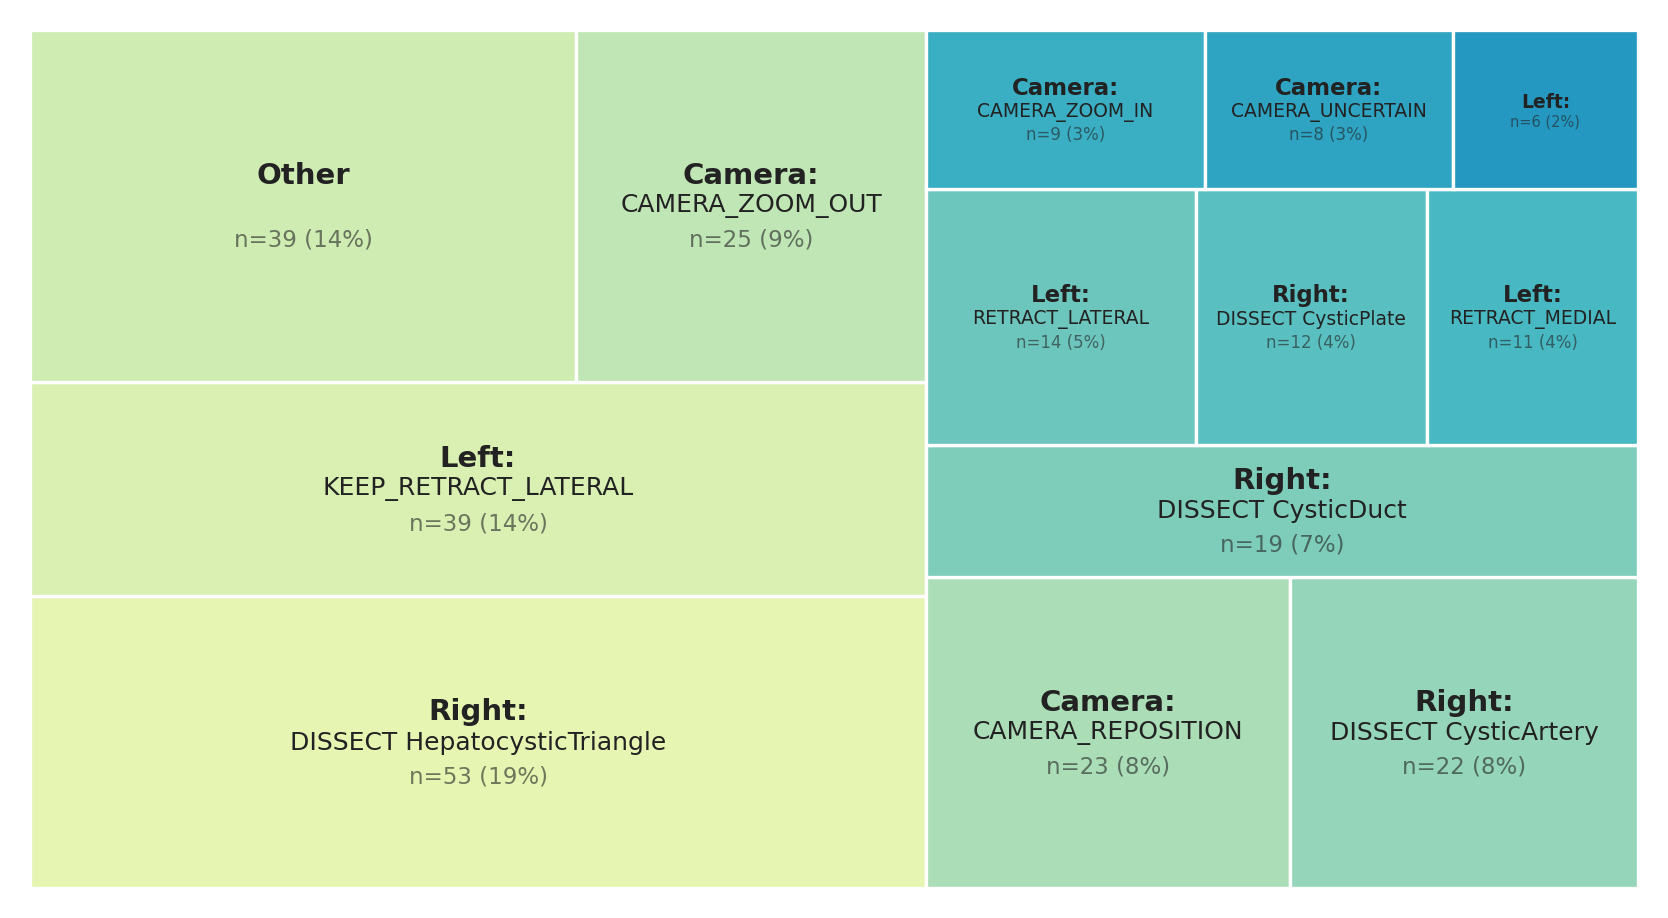

In [7]:
import os

try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from IPython.display import Image, display
except Exception as exc:
    raise RuntimeError('matplotlib and IPython are required for the treemap cell') from exc


def make_binary_treemap_rects(items, x=0.0, y=0.0, width=100.0, height=100.0):
    if not items:
        return []
    if len(items) == 1:
        return [{'x': x, 'y': y, 'dx': width, 'dy': height}]

    total = sum(size for _, size in items)
    running = 0
    split_idx = 0
    for idx, (_, size) in enumerate(items):
        if running + size >= total / 2:
            split_idx = idx + 1
            break
        running += size

    left_items = items[:split_idx]
    right_items = items[split_idx:]
    if not right_items:
        left_items = items[:-1]
        right_items = items[-1:]

    left_total = sum(size for _, size in left_items)
    frac = 0.5 if total == 0 else left_total / total

    if width >= height:
        left_width = width * frac
        return (
            make_binary_treemap_rects(left_items, x, y, left_width, height)
            + make_binary_treemap_rects(right_items, x + left_width, y, width - left_width, height)
        )

    top_height = height * frac
    return (
        make_binary_treemap_rects(left_items, x, y, width, top_height)
        + make_binary_treemap_rects(right_items, x, y + top_height, width, height - top_height)
    )


def make_treemap_flat(data_flat, output_dir, output_name):
    os.makedirs(output_dir, exist_ok=True)
    total = sum(data_flat.values())

    fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.0))
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_axis_off()

    items = sorted(data_flat.items(), key=lambda x: -x[1])
    sizes = [v for _, v in items]
    labels = [k for k, _ in items]

    rects = make_binary_treemap_rects(items, 0.0, 0.0, 100.0, 100.0)

    cmap = plt.cm.YlGnBu
    text_color = '#222222'
    n = len(items)
    for idx, (rec, label, size) in enumerate(zip(rects, labels, sizes)):
        rx, ry, rw, rh = rec['x'], rec['y'], rec['dx'], rec['dy']
        frac = 0.15 + 0.45 * (idx / max(n - 1, 1))
        color = cmap(frac)

        block_patch = mpatches.Rectangle(
            (rx, ry), rw, rh,
            linewidth=0.8, edgecolor='white', facecolor=color, zorder=2,
        )
        ax.add_patch(block_patch)

        pct = 100 * size / total
        area = rw * rh

        def _clipped_text(x, y, txt, fs, **kw):
            t = ax.text(x, y, txt, ha='center', va='center',
                        fontsize=fs, color=text_color, zorder=4, **kw)
            t.set_clip_path(block_patch)
            return t

        parts = label.split('\n')
        line_1 = parts[0]
        line_2 = parts[1] if len(parts) > 1 else ''

        if area > 350 and rw > 18 and rh > 14:
            _clipped_text(rx + rw / 2, ry + rh / 2 + 3.5, line_1, 7.0, fontweight='bold')
            _clipped_text(rx + rw / 2, ry + rh / 2 + 0.0, line_2, 6.0)
            _clipped_text(rx + rw / 2, ry + rh / 2 - 4.0, f'n={size} ({pct:.0f}%)', 5.5, alpha=0.6)
        elif area > 130 and rw > 12 and rh > 8:
            _clipped_text(rx + rw / 2, ry + rh / 2 + 2.5, line_1, 5.5, fontweight='bold')
            _clipped_text(rx + rw / 2, ry + rh / 2 - 0.3, line_2, 4.5)
            _clipped_text(rx + rw / 2, ry + rh / 2 - 3.0, f'n={size} ({pct:.0f}%)', 4.0, alpha=0.6)
        elif area > 50 and rw > 8 and rh > 5:
            _clipped_text(rx + rw / 2, ry + rh / 2 + 0.8, line_1, 4.5, fontweight='bold')
            _clipped_text(rx + rw / 2, ry + rh / 2 - 1.5, f'n={size} ({pct:.0f}%)', 3.5, alpha=0.6)

    plt.tight_layout(pad=0.5)

    pdf_path = os.path.join(output_dir, f'{output_name}.pdf')
    png_path = os.path.join(output_dir, f'{output_name}.png')
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.savefig(png_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    return pdf_path, png_path


TOP_N_ALL = 12
data_flat = {}
other_count = 0
for idx, (label, count) in enumerate(combo_counter.most_common()):
    if idx < TOP_N_ALL:
        data_flat[label] = count
    else:
        other_count += count
if other_count:
    data_flat['Other'] = other_count

TREEMAP_DIR = ROOT_DIR / 'figures'
pdf_path, png_path = make_treemap_flat(
    data_flat,
    TREEMAP_DIR,
    'treemap_action_combos_audit_v11_all',
)
print('wrote', pdf_path)
print('wrote', png_path)
display(Image(filename=str(png_path)))


## Audit-v11 Horizontal Bar Chart

This section makes a simpler audit-v11 summary plot with horizontal bars, annotated by both count and percentage.


wrote /mnt/md0/weiqiuy/surgent/figures/barh_action_combos_audit_v11_all.pdf
wrote /mnt/md0/weiqiuy/surgent/figures/barh_action_combos_audit_v11_all.png


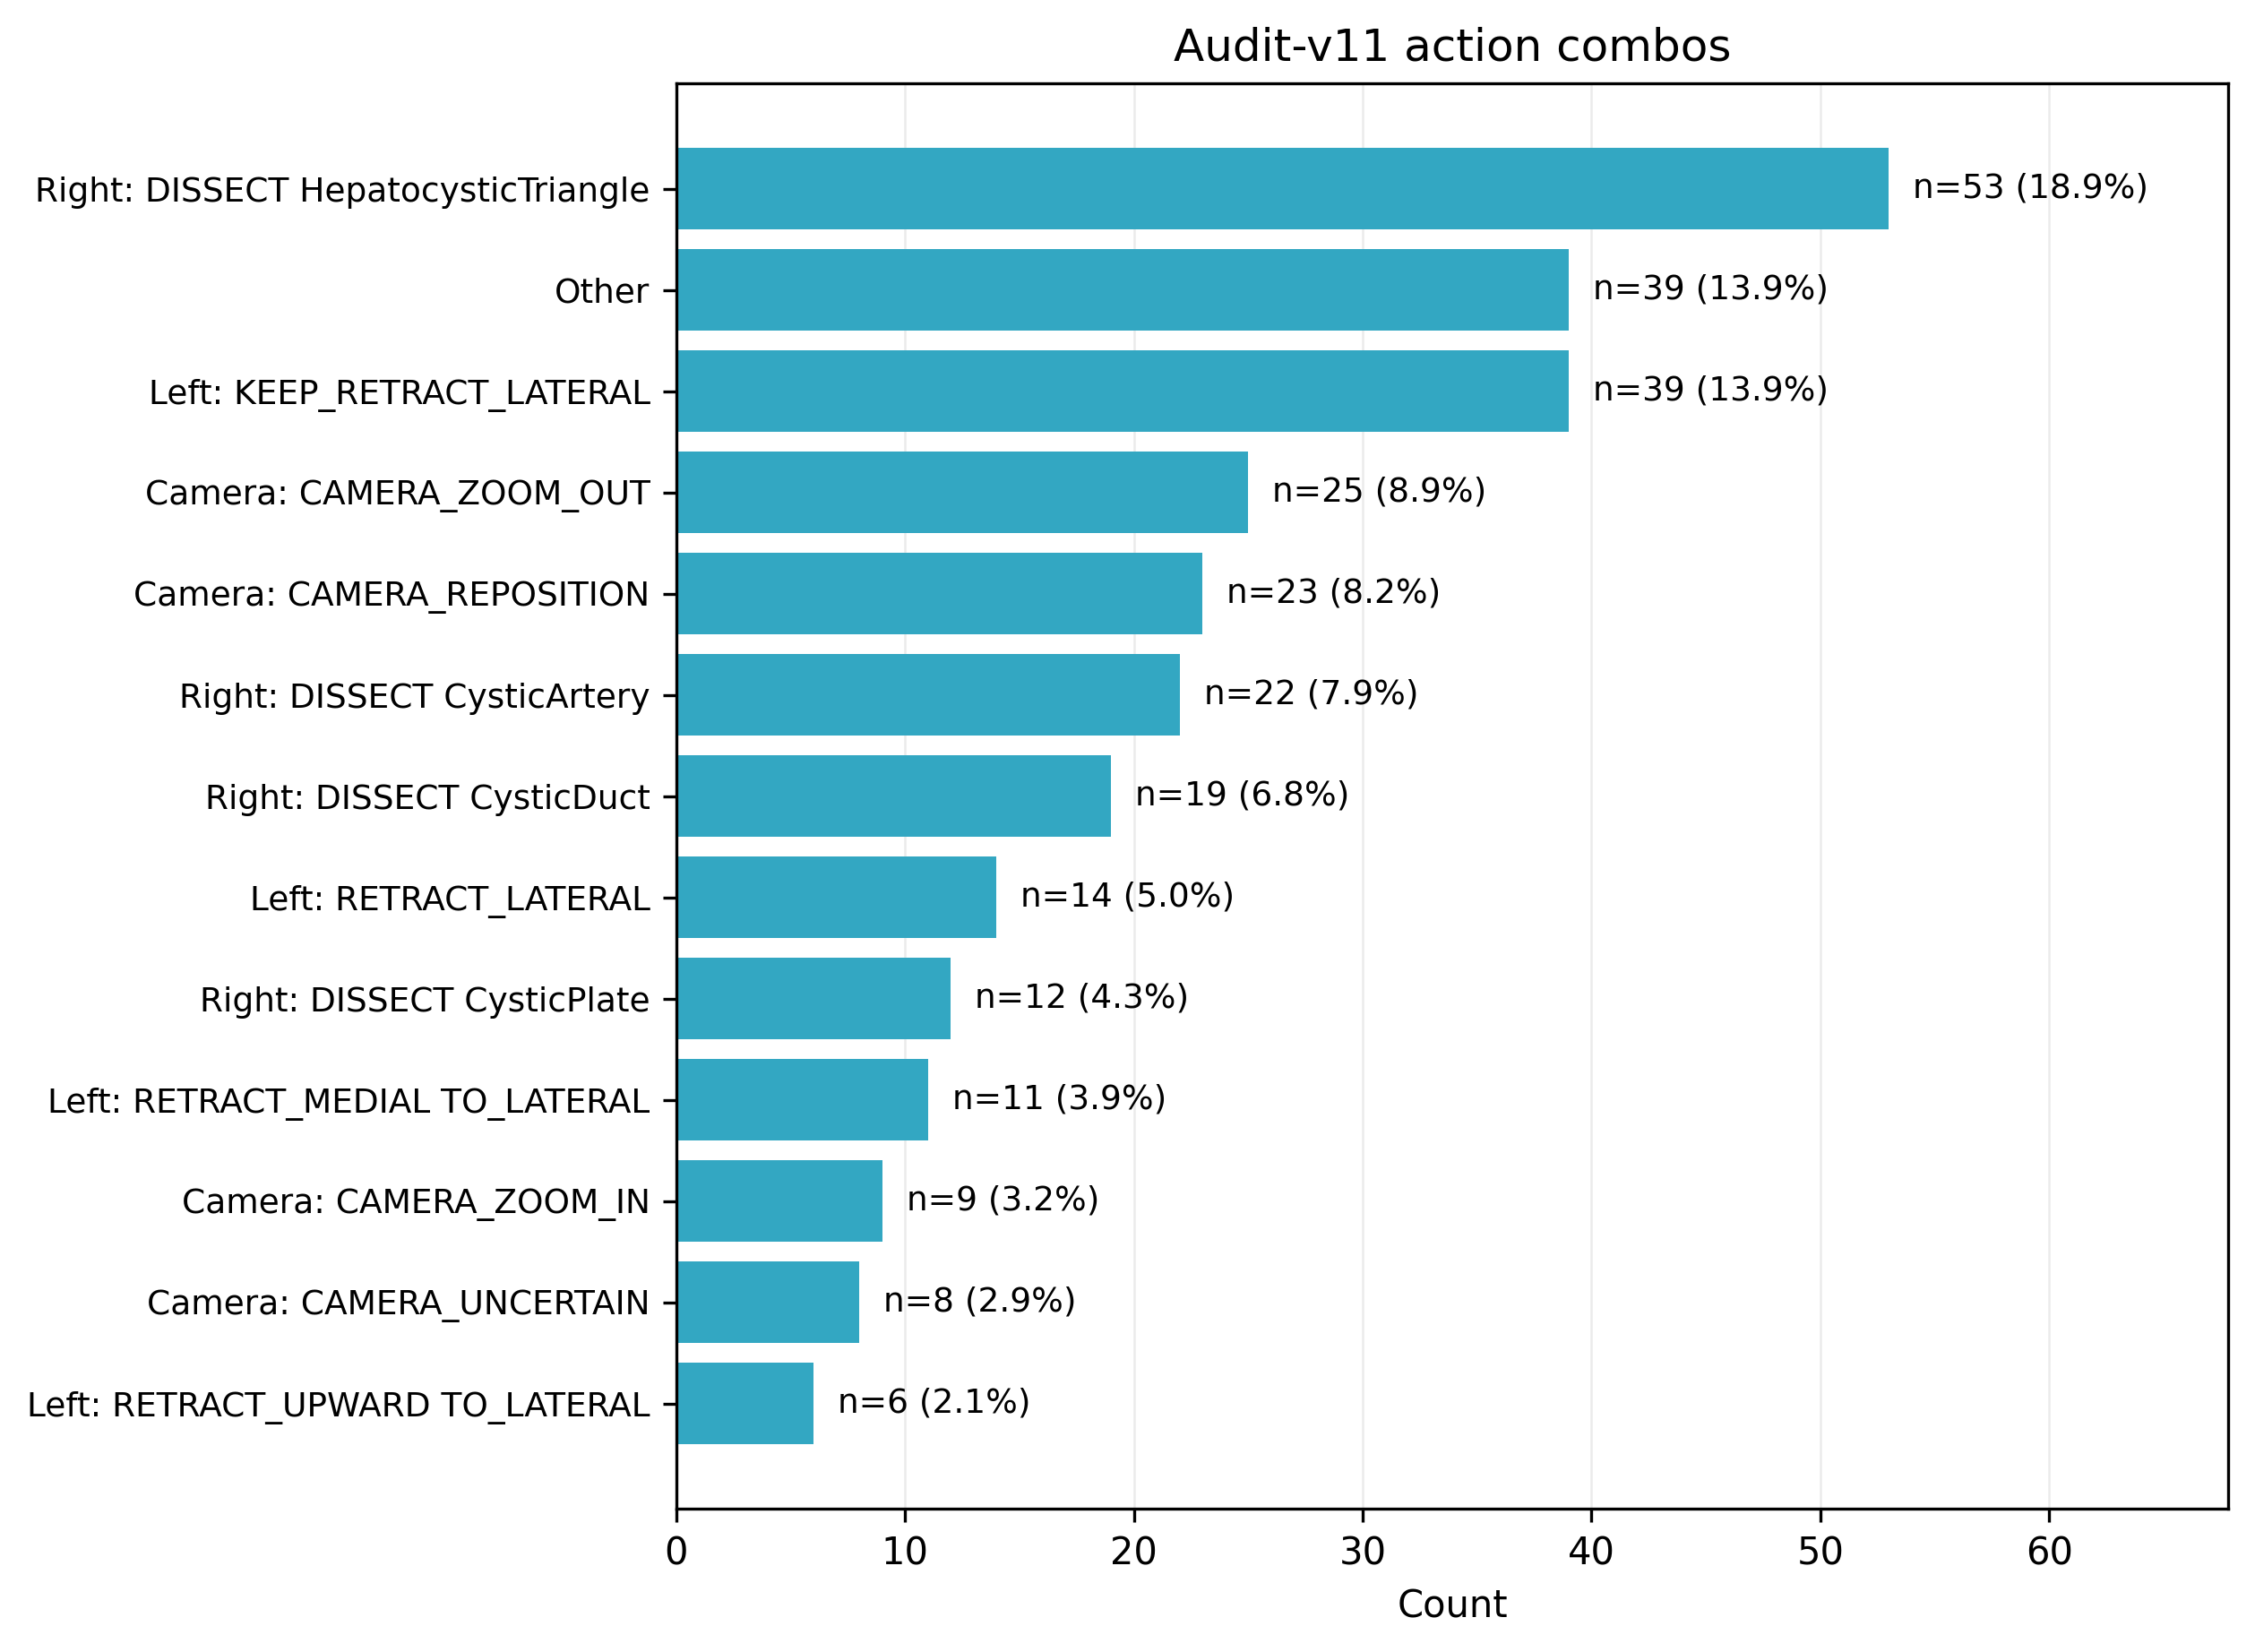

In [8]:
def make_horizontal_bar_chart(data_flat, output_dir, output_name):
    os.makedirs(output_dir, exist_ok=True)
    items = sorted(data_flat.items(), key=lambda x: x[1])
    labels = [k.replace('\n', ' ') for k, _ in items]
    counts = [v for _, v in items]
    total = sum(counts)

    fig_h = max(3.0, 0.42 * len(items) + 0.8)
    fig, ax = plt.subplots(1, 1, figsize=(8.5, fig_h))
    bars = ax.barh(range(len(items)), counts, color=plt.cm.YlGnBu(0.55))

    ax.set_yticks(range(len(items)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Count')
    ax.set_title('Audit-v11 action combos')
    ax.grid(axis='x', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)

    max_count = max(counts) if counts else 1
    ax.set_xlim(0, max_count * 1.28)

    for bar, count in zip(bars, counts):
        pct = 0.0 if total == 0 else 100.0 * count / total
        ax.text(
            bar.get_width() + max_count * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'n={count} ({pct:.1f}%)',
            va='center',
            ha='left',
            fontsize=9,
        )

    plt.tight_layout()
    pdf_path = os.path.join(output_dir, f'{output_name}.pdf')
    png_path = os.path.join(output_dir, f'{output_name}.png')
    plt.savefig(pdf_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.savefig(png_path, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close()
    return pdf_path, png_path


bar_pdf_path, bar_png_path = make_horizontal_bar_chart(
    data_flat,
    TREEMAP_DIR,
    'barh_action_combos_audit_v11_all',
)
print('wrote', bar_pdf_path)
print('wrote', bar_png_path)
display(Image(filename=str(bar_png_path)))


## Notes

- This table reflects the current split-task label space, not the older unified actor/tool/motion/target/goal taxonomy table.
- `Other` is currently derived directly from the data and is effectively just `ICG_SWITCH`.
- `Right` is the only actor that uses target context in this split taxonomy.
- Right-hand target contexts are normalized to the current simple version here:
  `between cystic artery and liver bed` is merged into `between cystic artery and cystic plate`,
  and older context variants such as `near cystic duct` and `on the side near the cystic plate`
  are collapsed to their simpler current forms.
